In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
dataset_path = "/content/dataset"

In [4]:
# Step 1: Load and preprocess the data
img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 317 images belonging to 3 classes.
Found 78 images belonging to 3 classes.


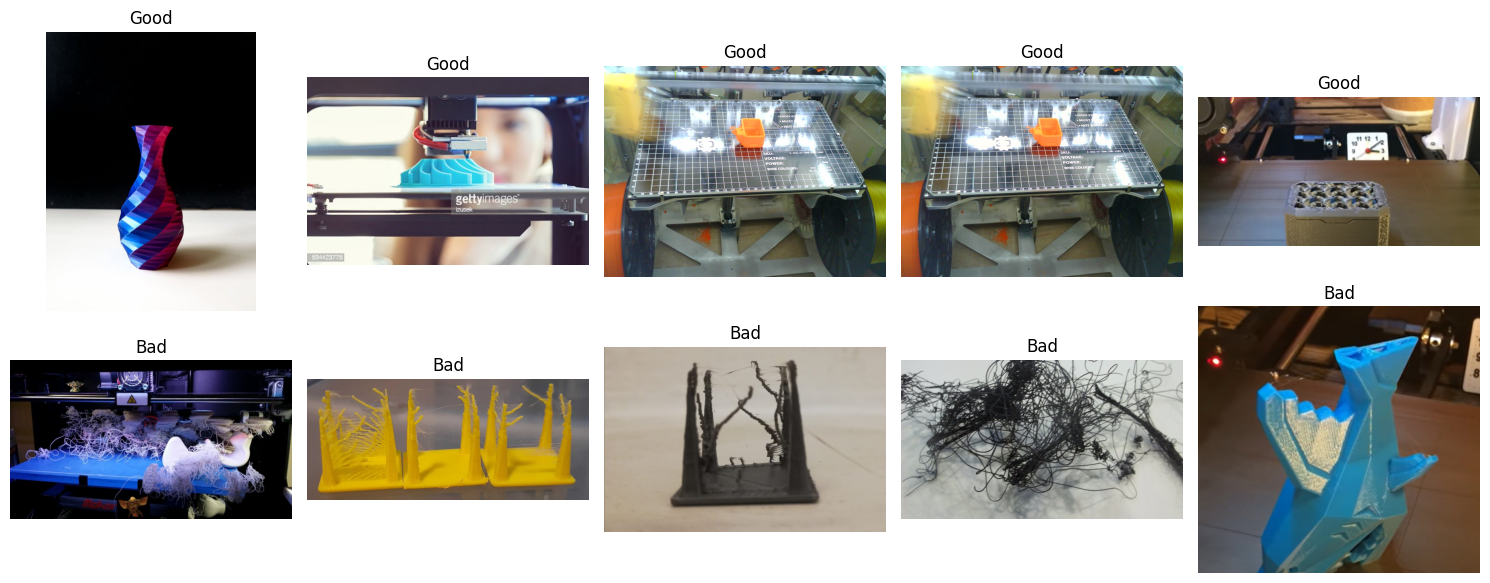

In [12]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

def show_sample_images(base_path, categories, samples_per_class=5):
    plt.figure(figsize=(15, 6))
    img_count = 1

    for label_index, category in enumerate(categories):
        category_path = os.path.join(base_path, category)
        image_files = [f for f in os.listdir(category_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
        selected_images = random.sample(image_files, min(samples_per_class, len(image_files)))

        for img_file in selected_images:
            img = Image.open(os.path.join(category_path, img_file))
            plt.subplot(len(categories), samples_per_class, img_count)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"{category}")
            img_count += 1

    plt.tight_layout()
    plt.show()

# Set your dataset path and categories
base_path = "/content/dataset"  # Adjust path if needed
categories = ['Good', 'Bad']

show_sample_images(base_path, categories)


In [5]:
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['Good', 'Bad']  # Force correct class names
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['Good', 'Bad']
)


Found 317 images belonging to 2 classes.
Found 78 images belonging to 2 classes.


In [7]:
# Step 2: Build the CNN model
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),  # <--- cleaner input
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Step 3: Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5136 - loss: 0.7576 - val_accuracy: 0.9103 - val_loss: 0.6155
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.6055 - loss: 0.6399 - val_accuracy: 0.9359 - val_loss: 0.4546
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6595 - loss: 0.5979 - val_accuracy: 0.8077 - val_loss: 0.3392
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7079 - loss: 0.5200 - val_accuracy: 0.9359 - val_loss: 0.2590
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7002 - loss: 0.4748 - val_accuracy: 0.8077 - val_loss: 0.3462
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8151 - loss: 0.3495 - val_accuracy: 0.7692 - val_loss: 0.6600
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8439 - loss: 0.3240 - val_accuracy: 0.7821 - val_loss: 0.4212
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9075 - loss: 0.2579 - val_accuracy: 0.8974 - val_loss:

In [9]:
# Step 4: Evaluate the model
val_generator.reset()
preds = model.predict(val_generator)
y_pred = np.round(preds).astype(int).flatten()
y_true = val_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Good', 'Bad']))

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step

Classification Report:
              precision    recall  f1-score   support

        Good       0.56      0.70      0.62        43
         Bad       0.46      0.31      0.37        35

    accuracy                           0.53        78
   macro avg       0.51      0.51      0.50        78
weighted avg       0.51      0.53      0.51        78



In [10]:
# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[30 13]
 [24 11]]


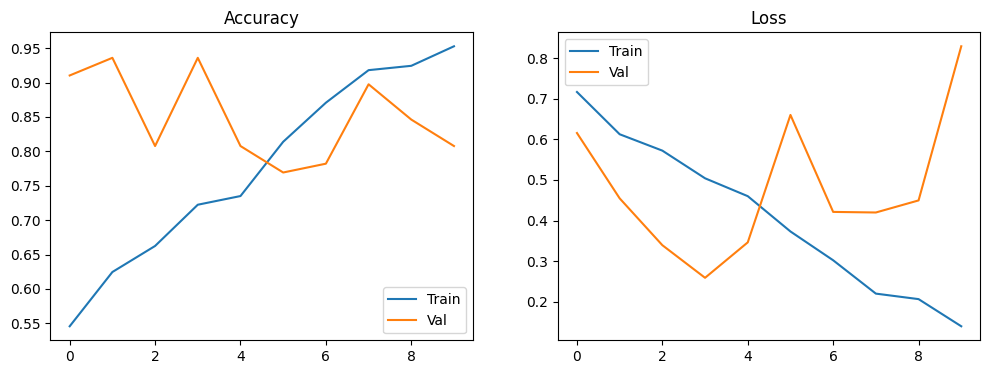

In [11]:
# Step 5: Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step


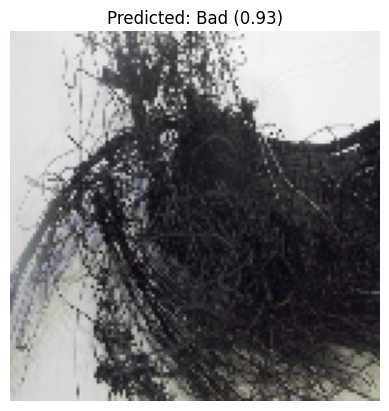

In [13]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(model, img_path, img_size=(128, 128)):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Predict
    prediction = model.predict(img_array)[0][0]
    label = "Bad" if prediction >= 0.5 else "Good"

    # Show image with prediction
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {label} ({prediction:.2f})")
    plt.show()

# Example usage
# Replace this with the path to your own test image
test_image_path = "/content/WhatsApp Image 2025-04-30 at 02.28.25_2f02f23d.jpg"
predict_image(model, test_image_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


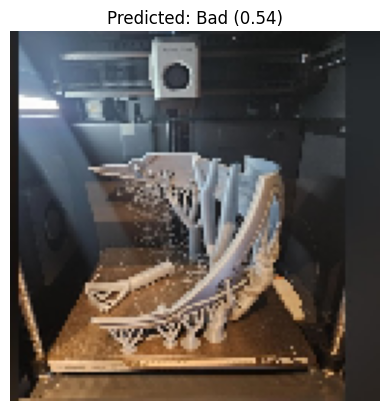

In [14]:
test_image_path = "/content/WhatsApp Image 2025-04-30 at 02.29.36_98b1a399.jpg"
predict_image(model, test_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


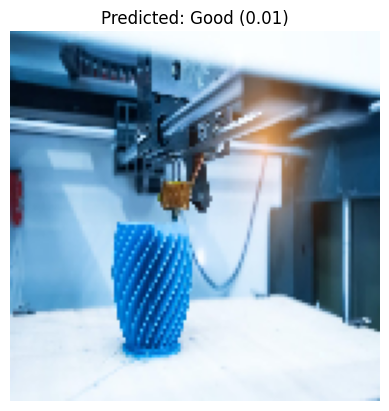

In [15]:
test_image_path = "/content/WhatsApp Image 2025-04-30 at 02.32.16_ea1aca44.jpg"
predict_image(model, test_image_path)